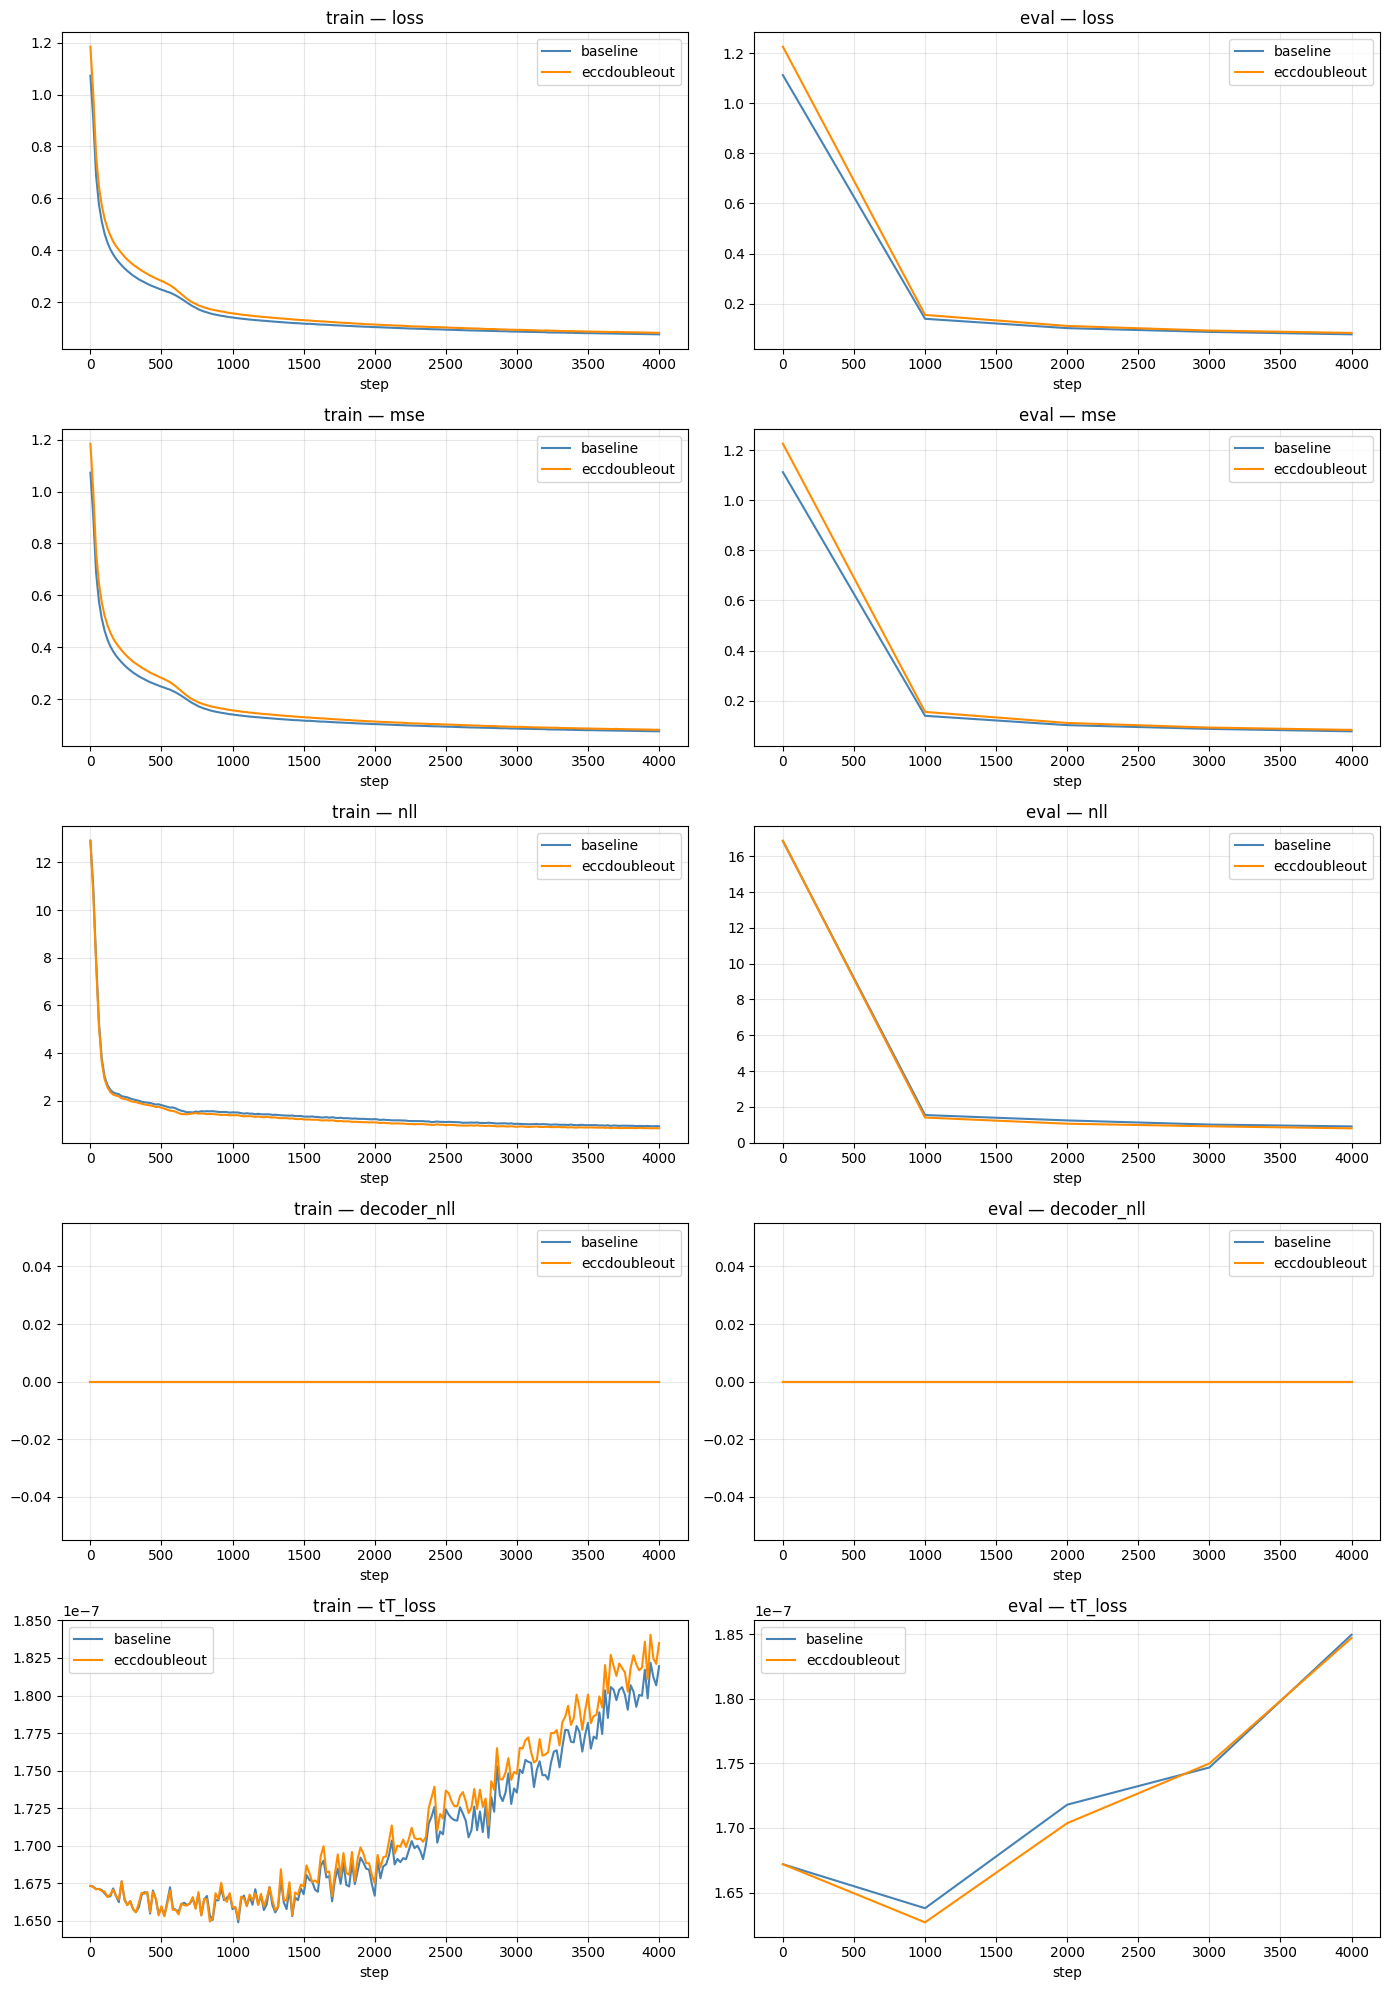

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

paths = {
    "baseline":    "diffusion_models/diffuseq_qqp_h128_lr0.0001_t2000_sqrt_lossaware_seed102_qqp20260515-15:53:34/progress.csv",
    "eccdoubleout": "diffusion_models/diffuseq_qqp_h128_lr0.0001_t2000_sqrt_lossaware_seed102_qqp20260526-14:11:38/progress.csv",
    
}

dfs = {}
for name, path in paths.items():
    df = pd.read_csv(path)
    df['step'] = df['step'].ffill()
    dfs[name] = df


metrics = ['loss', 'mse', 'nll', 'decoder_nll', 'tT_loss']
colors  = {'baseline': 'steelblue', 'eccdoubleout': 'darkorange'}

fig, axes = plt.subplots(len(metrics), 2, figsize=(14, 4 * len(metrics)))

for row, metric in enumerate(metrics):
    for col, split in enumerate(['train', 'eval']):
        ax = axes[row, col]
        col_name = metric if split == 'train' else f'eval_{metric}'
        for name, df in dfs.items():
            subset = df.dropna(subset=[col_name])
            subset = subset[subset['step'] <= 4000]
            ax.plot(subset['step'], subset[col_name], label=name, color=colors[name])
        ax.set_title(f'{split} — {metric}')
        ax.set_xlabel('step')
        ax.legend()
        ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_comparison.png', dpi=150)
plt.show()